<a href="https://colab.research.google.com/github/luana-leandra-da-silva-batista/Projeto-an-lise-dados/blob/main/analise_vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## importando bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns

##Configurações Iniciais e Carregamento do Arquivo

In [ ]:
print("--- Configurações Iniciais e Carregamento do Arquivo ---")

--- Configurações Iniciais e Carregamento do Arquivo ---


Configuração para melhorar a visualização dos gráficos

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Carregando o arquivo CSV diretamente, assumindo que já está disponível no ambiente


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

print("\n--- Carregamento do Arquivo CSV ---")

try:
    # Carregar o arquivo CSV diretamente, assumindo que já está disponível no ambiente.
    # USANDO decimal=',' para garantir que números com vírgula sejam lidos corretamente.
    # O delimitador é ';'.
    df = pd.read_csv('dados_dashboard_5mil_linhas.csv', delimiter=';', decimal=',')
    print("DataFrame 'dados_dashboard_5mil_linhas.csv' carregado com sucesso!")

except FileNotFoundError:
    print("ERRO: O arquivo 'dados_dashboard_5mil_linhas.csv' não foi encontrado.")
    print("Por favor, certifique-se de que o arquivo foi carregado para o ambiente do Google Colab (ex: arrastando e soltando na barra lateral esquerda) ou que o Google Drive está montado e o caminho está correto.")
    df = pd.DataFrame() # Cria um DataFrame vazio para evitar erros futuros

except Exception as e:
    print(f"ERRO inesperado ao carregar o DataFrame: {e}")
    df = pd.DataFrame()

# Verificação para continuar apenas se o DataFrame não estiver vazio
if df.empty:
    print("\nERRO: DataFrame está vazio. Não é possível prosseguir com a análise.")
else:
    print("\nVisão Geral Inicial do DataFrame:")
    print(df.info())
    print("\nPrimeiras 5 linhas do dataframe:")
    print(df.head())
    print("\nEstatísticas descritivas das colunas numéricas:")
    print(df.describe())


--- Carregamento do Arquivo CSV ---
DataFrame 'dados_dashboard_5mil_linhas.csv' carregado com sucesso!

Visão Geral Inicial do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID do Pedido        5000 non-null   int64  
 1   Data                5000 non-null   object 
 2   Vendedor            5000 non-null   object 
 3   Supervisor/Empresa  5000 non-null   object 
 4   Cidade              5000 non-null   object 
 5   Produto             5000 non-null   object 
 6   Categoria           5000 non-null   object 
 7   Quantidade          5000 non-null   int64  
 8   Preço Unitário      5000 non-null   float64
 9   Valor Total         5000 non-null   float64
dtypes: float64(2), int64(2), object(6)
memory usage: 390.8+ KB
None

Primeiras 5 linhas do dataframe:
   ID do Pedido        Data Vendedor Supervisor/Empresa        

Tratamento e limpeza de dados

In [ ]:
print("\n--- Tratamento e Limpeza de Dados ---")



--- Tratamento e Limpeza de Dados ---


In [ ]:

if df.empty:
    print("DataFrame vazio. Não é possível realizar o tratamento de dados.")
else:
    # 2.1. Conversão da coluna 'Data' para formato datetime
    if 'Data' in df.columns:
        df['Data'] = pd.to_datetime(df['Data'], errors='coerce', dayfirst=True)
        print("Coluna 'Data' convertida para datetime.")
    else:
        print("AVISO: Coluna 'Data' não encontrada para conversão de data.")

Coluna 'Data' convertida para datetime.


Verificação e garantia de tipos numéricos

In [ ]:
for col in ['Preço Unitário', 'Valor Total', 'Quantidade']:
        if col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
                df[col] = pd.to_numeric(df[col], errors='coerce')
                print(f"Coluna '{col}' convertida para tipo numérico (float).")
            elif pd.api.types.is_numeric_dtype(df[col]):
                print(f"Coluna '{col}' já está no formato numérico.")
            else:
                print(f"AVISO: Coluna '{col}' tem um tipo inesperado: {df[col].dtype}.")
        else:
            print(f"AVISO: Coluna '{col}' não encontrada.")

Coluna 'Preço Unitário' já está no formato numérico.
Coluna 'Valor Total' já está no formato numérico.
Coluna 'Quantidade' já está no formato numérico.


##Adicionando mais Supervisore no csv

In [ ]:
novos_supervisores_possiveis = [
        'João Silva', 'Maria Santos', 'Carlos Pereira', 'Ana Costa',
        'Bruno Lima',]

In [ ]:
supervisor_por_categoria = {
    'Eletrônicos': 'João Silva',
    'Vestuário': 'Maria Santos',
    'Alimentos': 'Carlos Pereira',
    'Casa e Decoração': 'Ana Costa',
    'Beleza e Cuidados Pessoais': 'Bruno Lima',
}

In [ ]:

    if 'Categoria' in df.columns and 'Supervisor/Empresa' in df.columns:
        df['Supervisor/Empresa_Novo'] = df['Categoria'].map(supervisor_por_categoria)
        linhas_nao_mapeadas = df['Supervisor/Empresa_Novo'].isnull()
        if linhas_nao_mapeadas.any():
            df.loc[linhas_nao_mapeadas, 'Supervisor/Empresa_Novo'] = np.random.choice(
                novos_supervisores_possiveis, size=linhas_nao_mapeadas.sum()
            )
        df['Supervisor/Empresa'] = df['Supervisor/Empresa_Novo']
        df.drop(columns=['Supervisor/Empresa_Novo'], inplace=True)
        print("Coluna 'Supervisor/Empresa' atualizada com novos supervisores (baseado em Categoria e aleatoriedade).")
    elif 'Supervisor/Empresa' in df.columns:
        df['Supervisor/Empresa'] = np.random.choice(novos_supervisores_possiveis, size=len(df))
        print("Coluna 'Supervisor/Empresa' atualizada com supervisores aleatórios (Sem coluna 'Categoria').")
    else:
        print("AVISO: Coluna 'Supervisor/Empresa' não encontrada para modificação ou criação.")

    print("\nContagem de valores únicos na coluna 'Supervisor/Empresa' após a modificação:")
    print(df['Supervisor/Empresa'].value_counts())

    # 2.4. Verificação e tratamento de valores ausentes (NaN)
    print("\nVerificando valores ausentes:")
    print(df.isnull().sum())

    initial_rows = df.shape[0]
    df.dropna(subset=['Data', 'Valor Total'], inplace=True)
    if df.shape[0] < initial_rows:
        print(f"Removidas {initial_rows - df.shape[0]} linhas com valores ausentes em 'Data' ou 'Valor Total'.")
    else: # ESTE É O BLOCO 'ELSE' QUE ESTAVA CAUSANDO O ERRO DE INDENTAÇÃO SE COPIADO ISOLADAMENTE
        print("Nenhuma linha com valores ausentes críticos ('Data', 'Valor Total') foi removida.")

Coluna 'Supervisor/Empresa' atualizada com novos supervisores (baseado em Categoria e aleatoriedade).

Contagem de valores únicos na coluna 'Supervisor/Empresa' após a modificação:
Supervisor/Empresa
João Silva        1044
Ana Costa         1014
Carlos Pereira    1006
Maria Santos       979
Bruno Lima         957
Name: count, dtype: int64

Verificando valores ausentes:
ID do Pedido          0
Data                  0
Vendedor              0
Supervisor/Empresa    0
Cidade                0
Produto               0
Categoria             0
Quantidade            0
Preço Unitário        0
Valor Total           0
dtype: int64
Nenhuma linha com valores ausentes críticos ('Data', 'Valor Total') foi removida.


Verificando as duplicadas

In [ ]:


    print("\nVerificando linhas duplicadas")
    num_duplicatas = df.duplicated().sum()
    print(f"Número de linhas duplicadas: {num_duplicatas}")

    if num_duplicatas > 0:
        print(f"Foram encontradas {num_duplicatas} linhas duplicadas. Removendo...")
        df.drop_duplicates(inplace=True)
        print("Duplicatas removidas.")
    else:
        print("Nenhuma duplicata encontrada.")

    print("\nShape do DataFrame após tratamento:")
    print(df.shape)



Verificando linhas duplicadas
Número de linhas duplicadas: 0
Nenhuma duplicata encontrada.

Shape do DataFrame após tratamento:
(5000, 10)


##Análise Exploratória de Dados (EDA)##

Distribuição de Vendas por Categoria


Distribuição de Vendas por Categoria:
Categoria
Eletrônicos                   4318260.0
Casa e Decoração               462750.0
Vestuário                      277510.0
Beleza e Cuidados Pessoais     152361.0
Alimentos                       45165.6
Name: Valor Total, dtype: float64


/tmp/ipython-input-2252915096.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendas_por_categoria.index, y=vendas_por_categoria.values, palette='coolwarm')


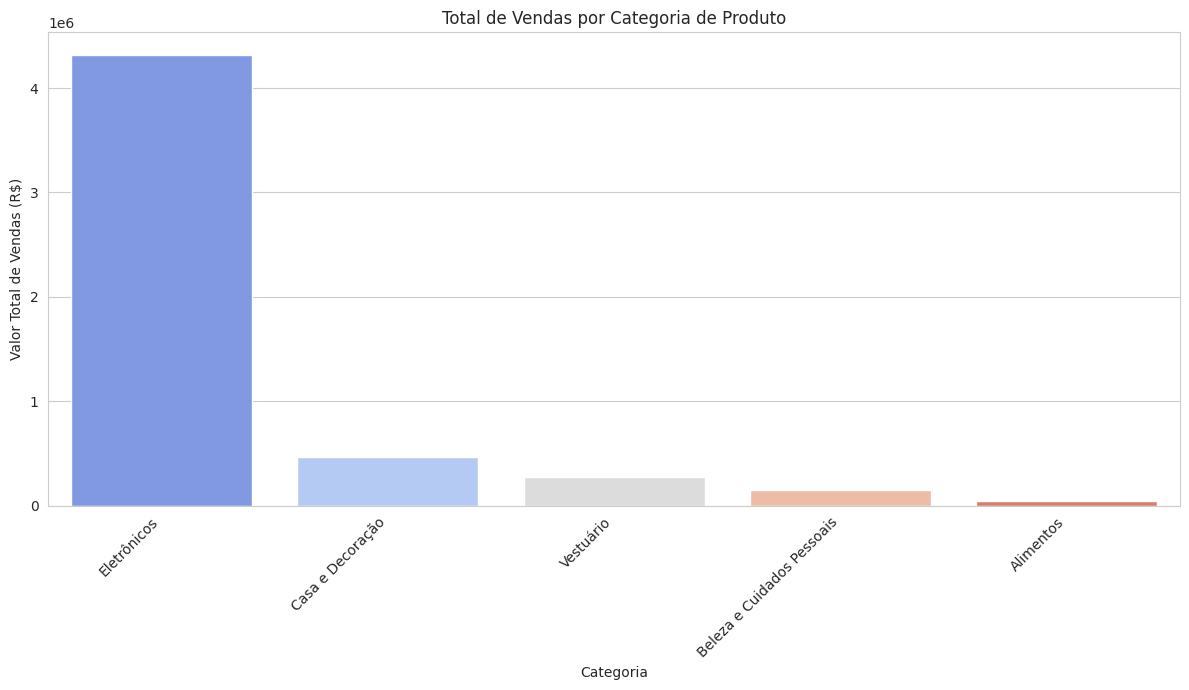

In [ ]:
if 'Categoria' in df.columns and 'Valor Total' in df.columns:
    print("\nDistribuição de Vendas por Categoria:")
    vendas_por_categoria = df.groupby('Categoria')['Valor Total'].sum().sort_values(ascending=False)
    print(vendas_por_categoria)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=vendas_por_categoria.index, y=vendas_por_categoria.values, palette='coolwarm')
    plt.title('Total de Vendas por Categoria de Produto')
    plt.xlabel('Categoria')
    plt.ylabel('Valor Total de Vendas (R$)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("AVISO: Colunas 'Categoria' ou 'Valor Total' não encontradas para análise de vendas por categoria.")

## Top 10 Produtos Mais Vendidos em Valor Total ##


Top 10 Produtos Mais Vendidos (Valor Total):
Produto
Calça Jeans              61100.0
Fone de Ouvido ABC       65160.0
Perfume Essência         92400.0
Tênis Esportivo         125160.0
Tapete Sala             165200.0
Mesa de Centro          234450.0
Monitor Samsung 32"     465000.0
Smartphone XYZ          842800.0
Televisão 50"           988800.0
Notebook Gamer         1956500.0
Name: Valor Total, dtype: float64


/tmp/ipython-input-302381866.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_produtos_valor.values, y=top_produtos_valor.index, palette='crest')


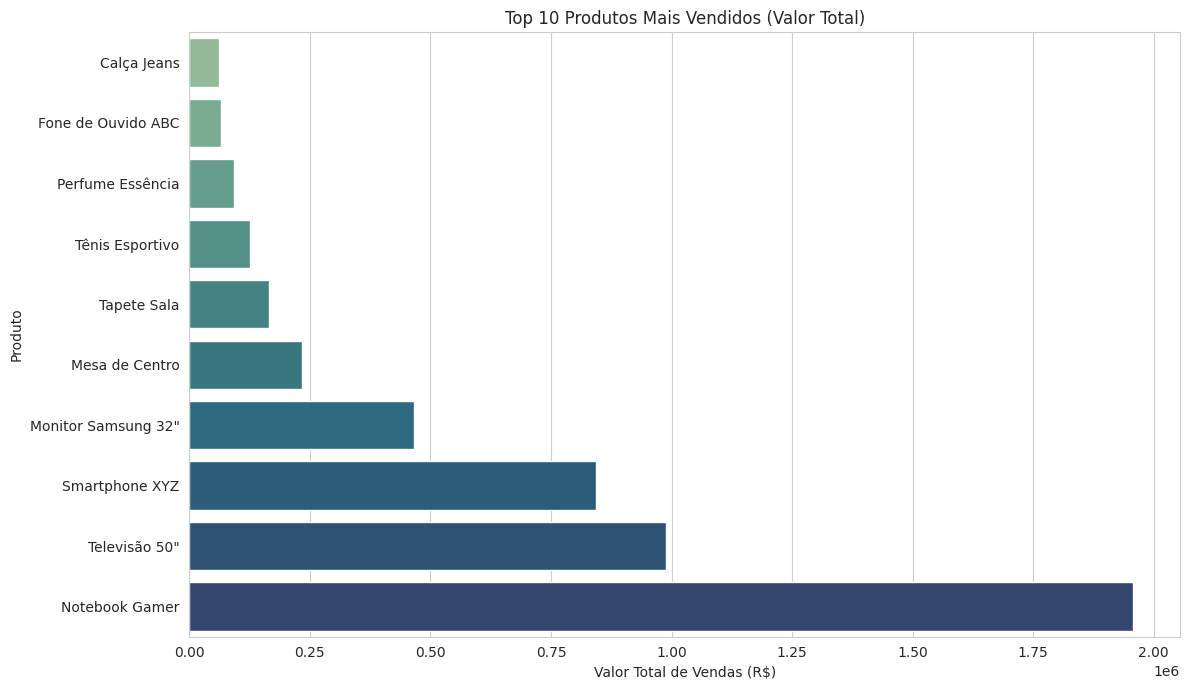

In [ ]:
    if 'Produto' in df.columns and 'Valor Total' in df.columns:
        top_produtos_valor = df.groupby('Produto')['Valor Total'].sum().nlargest(10).sort_values(ascending=True)
        print("\nTop 10 Produtos Mais Vendidos (Valor Total):")
        print(top_produtos_valor)

        plt.figure(figsize=(12, 7))
        sns.barplot(x=top_produtos_valor.values, y=top_produtos_valor.index, palette='crest')
        plt.title('Top 10 Produtos Mais Vendidos (Valor Total)')
        plt.xlabel('Valor Total de Vendas (R$)')
        plt.ylabel('Produto')
        plt.tight_layout()
        plt.show()
    else:
        print("AVISO: Colunas 'Produto' ou 'Valor Total' não encontradas para análise de top produtos.")



Top 10 Produtos Mais Vendidos (Quantidade):
Produto
Pão de Forma       485
Vestido Verão      489
Arroz 5kg          495
Açúcar 1kg         509
Shampoo 400ml      516
Mesa de Centro     521
Leite 1L           526
Camisa Polo        527
Vaso Decorativo    539
Feijão 1kg         556
Name: Quantidade, dtype: int64


/tmp/ipython-input-2235062985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_produtos_quantidade.values, y=top_produtos_quantidade.index, palette='viridis')


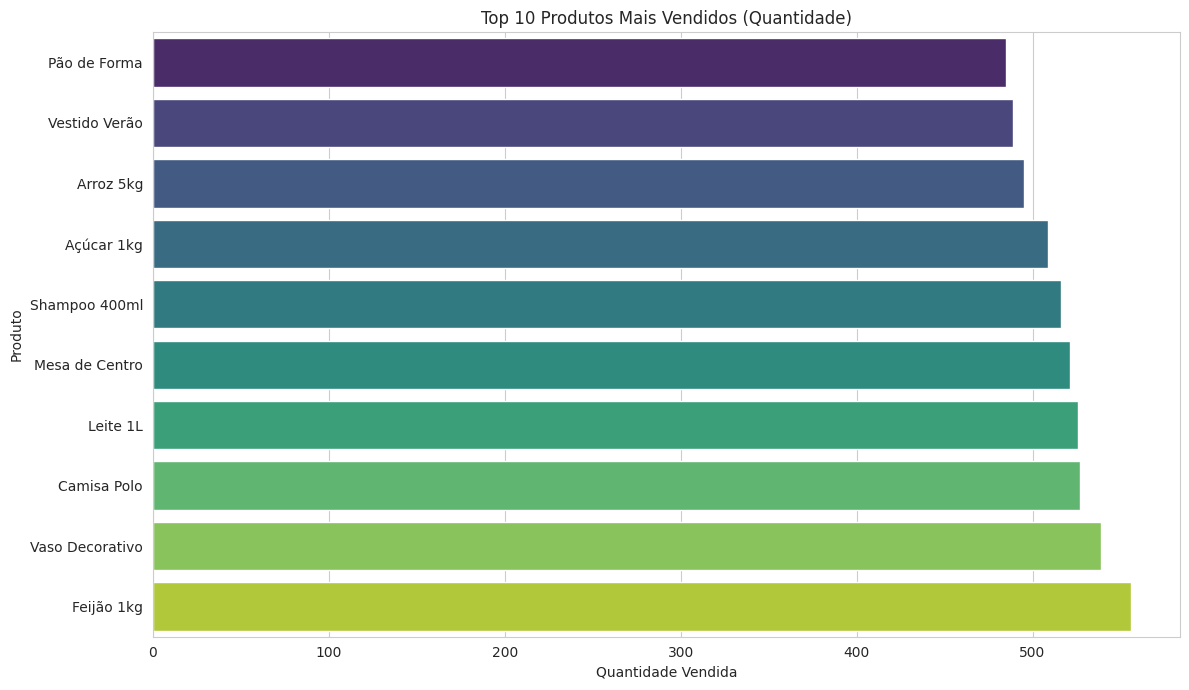

In [ ]:
if 'Produto' in df.columns and 'Quantidade' in df.columns:
    top_produtos_quantidade = df.groupby('Produto')['Quantidade'].sum().nlargest(10).sort_values(ascending=True)
    print("\nTop 10 Produtos Mais Vendidos (Quantidade):")
    print(top_produtos_quantidade)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=top_produtos_quantidade.values, y=top_produtos_quantidade.index, palette='viridis')
    plt.title('Top 10 Produtos Mais Vendidos (Quantidade)')
    plt.xlabel('Quantidade Vendida')
    plt.ylabel('Produto')
    plt.tight_layout()
    plt.show()
else:
    print("AVISO: Colunas 'Produto' ou 'Quantidade' não encontradas para análise de top produtos por quantidade.")

 Distribuição de Vendas por Cidade


Total de Vendas por Cidade:
Cidade
Rio de Janeiro    601633.9
Salvador          586631.0
Belo Horizonte    536934.3
Recife            526326.6
São Paulo         524681.9
Porto Alegre      514424.3
Brasília          512312.8
Florianópolis     509132.2
Curitiba          505165.3
Fortaleza         438804.3
Name: Valor Total, dtype: float64


/tmp/ipython-input-2426845871.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendas_por_cidade.index, y=vendas_por_cidade.values, palette='magma')


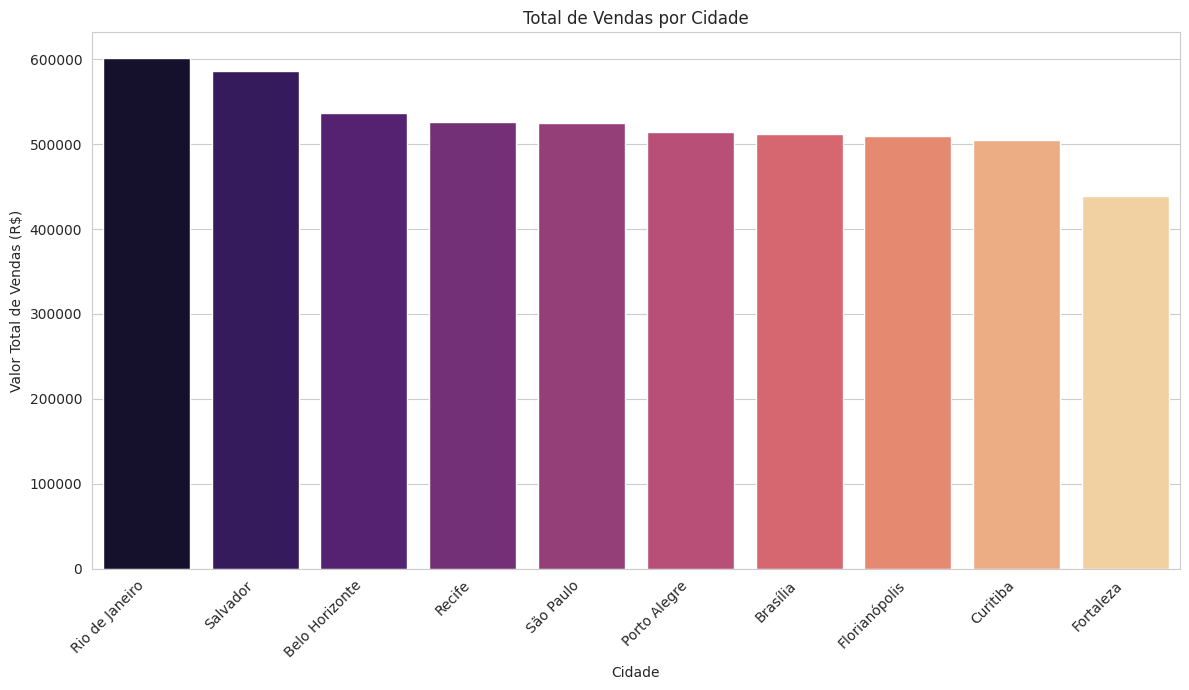

In [ ]:
if 'Cidade' in df.columns and 'Valor Total' in df.columns:
    vendas_por_cidade = df.groupby('Cidade')['Valor Total'].sum().sort_values(ascending=False)
    print("\nTotal de Vendas por Cidade:")
    print(vendas_por_cidade)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=vendas_por_cidade.index, y=vendas_por_cidade.values, palette='magma')
    plt.title('Total de Vendas por Cidade')
    plt.xlabel('Cidade')
    plt.ylabel('Valor Total de Vendas (R$)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("AVISO: Colunas 'Cidade' ou 'Valor Total' não encontradas para análise de vendas por cidade.")

 ## Análise de Outliers

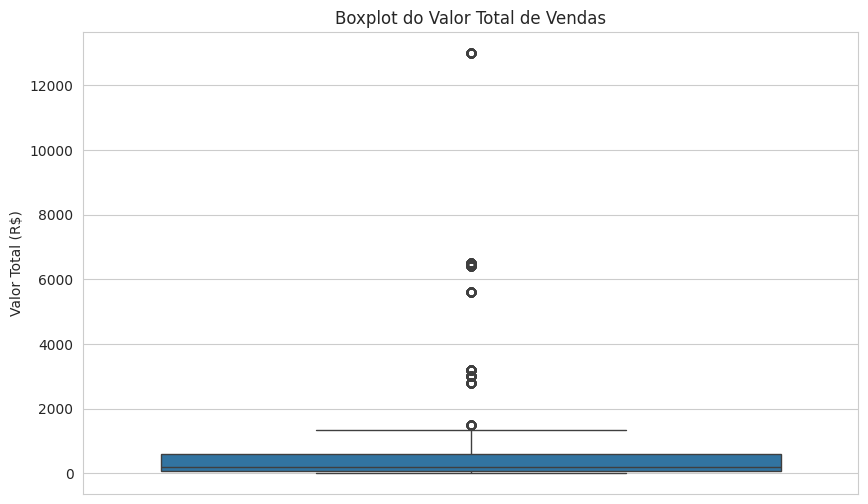


Observação sobre Outliers no 'Valor Total':
O boxplot acima pode indicar a presença de outliers (valores muito altos).
Dependendo do objetivo da análise, esses outliers podem precisar de tratamento específico (remoção, winsorização, etc.)
Para este dashboard, os outliers não foram removidos para manter o valor real total, mas é um ponto a ser considerado em análises mais aprofundadas.

--- Parte 4: Dashboard Detalhado por Supervisor ---


In [ ]:
if 'Valor Total' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(y=df['Valor Total'])
    plt.title('Boxplot do Valor Total de Vendas')
    plt.ylabel('Valor Total (R$)')
    plt.show()
    print("\nObservação sobre Outliers no 'Valor Total':")
    print("O boxplot acima pode indicar a presença de outliers (valores muito altos).")
    print("Dependendo do objetivo da análise, esses outliers podem precisar de tratamento específico (remoção, winsorização, etc.)")
    print("Para este dashboard, os outliers não foram removidos para manter o valor real total, mas é um ponto a ser considerado em análises mais aprofundadas.")
else:
    print("AVISO: Coluna 'Valor Total' não encontrada para análise de outliers.")


# --- 4. Dashboard Detalhado por Supervisor ---
print("\n--- Parte 4: Dashboard Detalhado por Supervisor ---")

## Total de Vendas por Supervisor

/tmp/ipython-input-1978075496.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendas_por_supervisor.index, y=vendas_por_supervisor.values, palette='viridis')


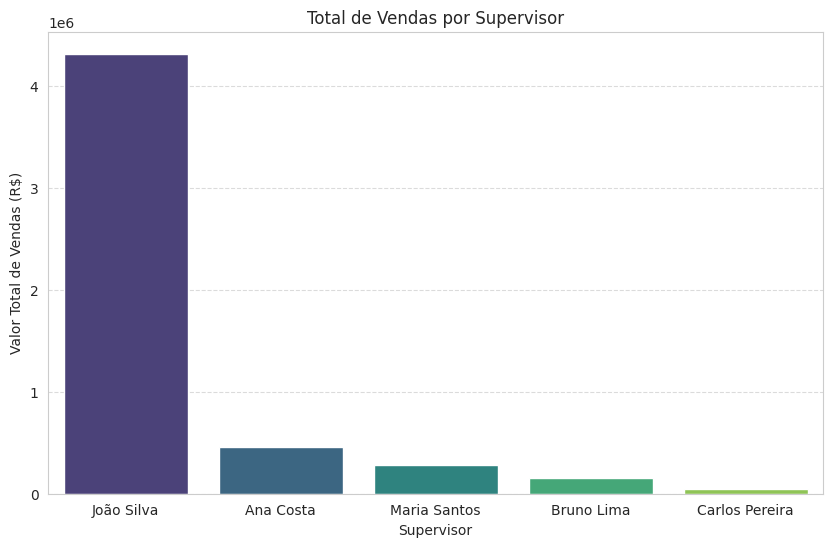


Total de Vendas por Supervisor:
Supervisor/Empresa
João Silva        4318260.0
Ana Costa          462750.0
Maria Santos       277510.0
Bruno Lima         152361.0
Carlos Pereira      45165.6
Name: Valor Total, dtype: float64


In [ ]:
if 'Supervisor/Empresa' in df.columns and 'Valor Total' in df.columns:
    vendas_por_supervisor = df.groupby('Supervisor/Empresa')['Valor Total'].sum().sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=vendas_por_supervisor.index, y=vendas_por_supervisor.values, palette='viridis')
    plt.title('Total de Vendas por Supervisor')
    plt.xlabel('Supervisor')
    plt.ylabel('Valor Total de Vendas (R$)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    print("\nTotal de Vendas por Supervisor:")
    print(vendas_por_supervisor)
else:
    print("AVISO: Colunas 'Supervisor/Empresa' ou 'Valor Total' não encontradas para análise de vendas por supervisor.")

## Quantidade de Itens Vendidos por Supervisor ##

/tmp/ipython-input-3725372377.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=itens_por_supervisor.index, y=itens_por_supervisor.values, palette='plasma')


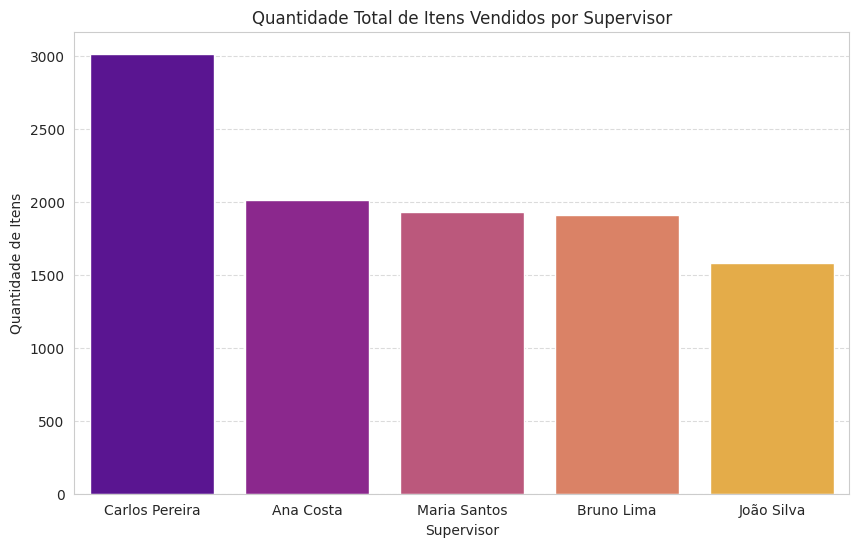


Quantidade de Itens Vendidos por Supervisor:
Supervisor/Empresa
Carlos Pereira    3014
Ana Costa         2014
Maria Santos      1933
Bruno Lima        1912
João Silva        1583
Name: Quantidade, dtype: int64


In [ ]:
if 'Supervisor/Empresa' in df.columns and 'Quantidade' in df.columns:
    itens_por_supervisor = df.groupby('Supervisor/Empresa')['Quantidade'].sum().sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=itens_por_supervisor.index, y=itens_por_supervisor.values, palette='plasma')
    plt.title('Quantidade Total de Itens Vendidos por Supervisor')
    plt.xlabel('Supervisor')
    plt.ylabel('Quantidade de Itens')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    print("\nQuantidade de Itens Vendidos por Supervisor:")
    print(itens_por_supervisor)
else:
    print("AVISO: Colunas 'Supervisor/Empresa' ou 'Quantidade' não encontradas para análise de itens vendidos por supervisor.")

 ## Média de Vendas por Pedidos ##

/tmp/ipython-input-3093003330.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_venda_por_pedido_supervisor['Supervisor/Empresa'], y=media_venda_por_pedido_supervisor['Media_Por_Pedido'], palette='cividis')


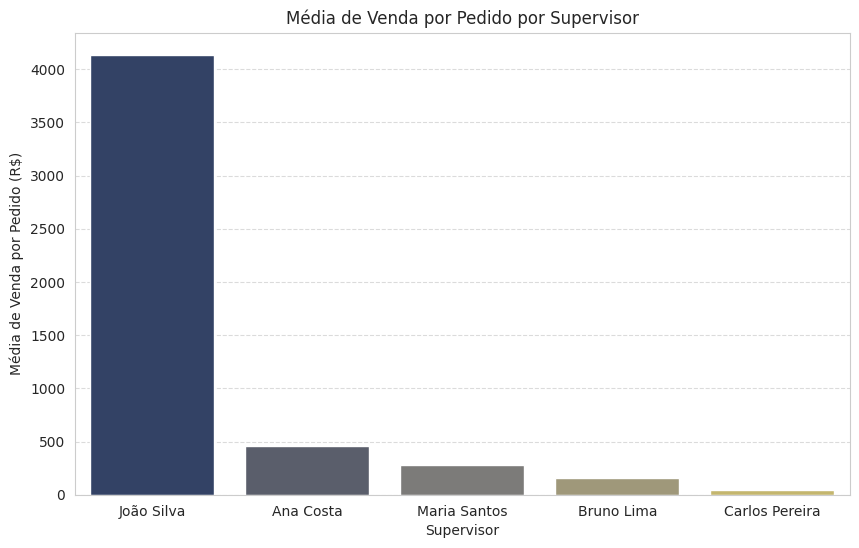


Média de Venda por Pedido por Supervisor:
  Supervisor/Empresa  Media_Por_Pedido
3         João Silva       4136.264368
0          Ana Costa        456.360947
4       Maria Santos        283.462717
1         Bruno Lima        159.206897
2     Carlos Pereira         44.896223


In [ ]:
if 'Supervisor/Empresa' in df.columns and 'Valor Total' in df.columns and 'ID do Pedido' in df.columns:
    media_venda_por_pedido_supervisor = df.groupby('Supervisor/Empresa').agg(
        total_vendas=('Valor Total', 'sum'),
        total_pedidos=('ID do Pedido', 'nunique') # Conta pedidos únicos
    ).reset_index()

    # Evita divisão por zero se houver algum supervisor sem pedidos
    media_venda_por_pedido_supervisor['Media_Por_Pedido'] = media_venda_por_pedido_supervisor.apply(
        lambda row: row['total_vendas'] / row['total_pedidos'] if row['total_pedidos'] > 0 else 0, axis=1
    )
    media_venda_por_pedido_supervisor = media_venda_por_pedido_supervisor.sort_values(by='Media_Por_Pedido', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=media_venda_por_pedido_supervisor['Supervisor/Empresa'], y=media_venda_por_pedido_supervisor['Media_Por_Pedido'], palette='cividis')
    plt.title('Média de Venda por Pedido por Supervisor')
    plt.xlabel('Supervisor')
    plt.ylabel('Média de Venda por Pedido (R$)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    print("\nMédia de Venda por Pedido por Supervisor:")
    print(media_venda_por_pedido_supervisor[['Supervisor/Empresa', 'Media_Por_Pedido']])
else:
    print("AVISO: Colunas 'Supervisor/Empresa', 'Valor Total' ou 'ID do Pedido' não encontradas para análise de média de venda por pedido.")

## Vendas por Matriz e Supervisor e categorias ##

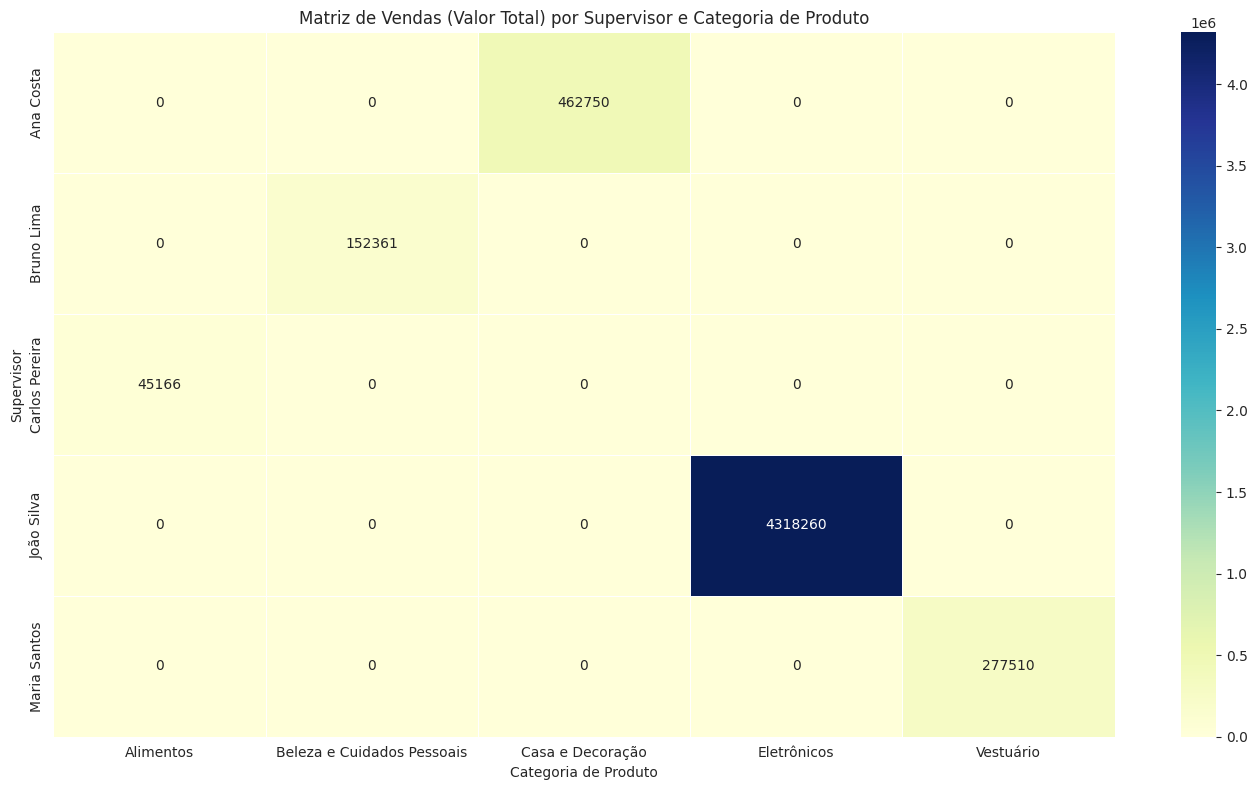


Matriz de Vendas por Supervisor e Categoria:
Categoria           Alimentos  Beleza e Cuidados Pessoais  Casa e Decoração  \
Supervisor/Empresa                                                            
Ana Costa                 0.0                         0.0          462750.0   
Bruno Lima                0.0                    152361.0               0.0   
Carlos Pereira        45165.6                         0.0               0.0   
João Silva                0.0                         0.0               0.0   
Maria Santos              0.0                         0.0               0.0   

Categoria           Eletrônicos  Vestuário  
Supervisor/Empresa                          
Ana Costa                   0.0        0.0  
Bruno Lima                  0.0        0.0  
Carlos Pereira              0.0        0.0  
João Silva            4318260.0        0.0  
Maria Santos                0.0   277510.0  


In [ ]:
    if 'Supervisor/Empresa' in df.columns and 'Categoria' in df.columns and 'Valor Total' in df.columns:
        vendas_categoria_supervisor_pivot = df.pivot_table(
            index='Supervisor/Empresa',
            columns='Categoria',
            values='Valor Total',
            aggfunc='sum',
            fill_value=0
        )

        plt.figure(figsize=(14, 8))
        sns.heatmap(vendas_categoria_supervisor_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
        plt.title('Matriz de Vendas (Valor Total) por Supervisor e Categoria de Produto')
        plt.xlabel('Categoria de Produto')
        plt.ylabel('Supervisor')
        plt.tight_layout()
        plt.show()
        print("\nMatriz de Vendas por Supervisor e Categoria:")
        print(vendas_categoria_supervisor_pivot)
    else:
        print("AVISO: Colunas 'Supervisor/Empresa' ou 'Categoria' ou 'Valor Total' não encontradas para matriz de vendas.")


 ## Desempenho de Vendedores por Supervisor Top 3


Desempenho de Vendedores por Supervisor:

Top 3 Vendedores por Supervisor (por Valor Total de Vendas):
   Supervisor/Empresa Vendedor  Valor Total
0           Ana Costa   Otávio      30025.0
1           Ana Costa    Sofia      28825.0
2           Ana Costa   Felipe      27250.0
3          Bruno Lima  Letícia      10697.0
4          Bruno Lima    Bruno      10121.0
5          Bruno Lima    Paula       9732.0
6      Carlos Pereira    Paula       3101.5
7      Carlos Pereira   Otávio       2955.0
8      Carlos Pereira  Valéria       2823.4
9          João Silva  Valéria     268460.0
10         João Silva    Paula     264820.0
11         João Silva   Thiago     262240.0
12       Maria Santos   Felipe      17845.0
13       Maria Santos   Thiago      16850.0
14       Maria Santos  Eduarda      16400.0


/tmp/ipython-input-3926563076.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_n_vendedores_por_supervisor = vendas_vendedor_supervisor.groupby('Supervisor/Empresa', group_keys=False).apply(
/tmp/ipython-input-3926563076.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Valor Total', y='Vendedor', data=data_to_plot, ax=axes[i], palette='Blues_d')
/tmp/ipython-input-3926563076.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=F

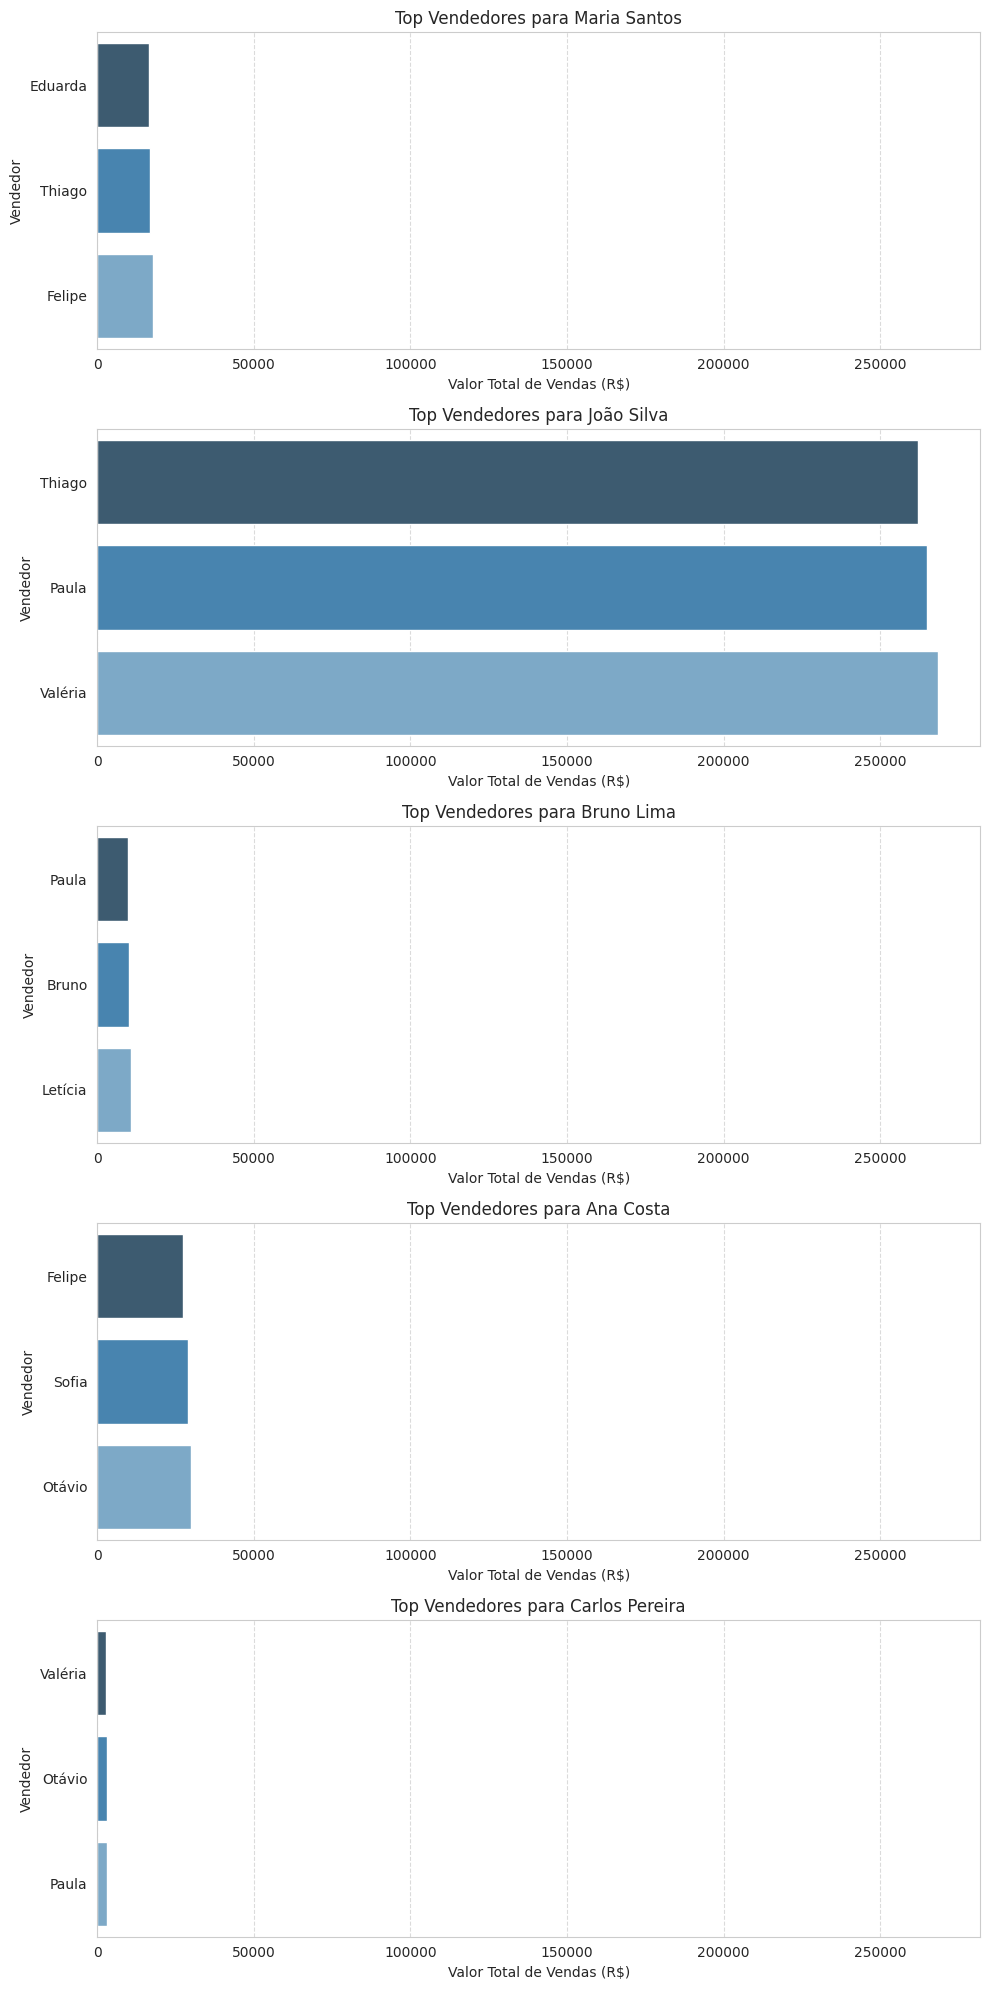

In [ ]:
if 'Supervisor/Empresa' in df.columns and 'Vendedor' in df.columns and 'Valor Total' in df.columns:
    print("\nDesempenho de Vendedores por Supervisor:")
    vendas_vendedor_supervisor = df.groupby(['Supervisor/Empresa', 'Vendedor'])['Valor Total'].sum().reset_index()

    top_n_vendedores_por_supervisor = vendas_vendedor_supervisor.groupby('Supervisor/Empresa', group_keys=False).apply(
        lambda x: x.nlargest(3, 'Valor Total')
    ).reset_index(drop=True)

    print("\nTop 3 Vendedores por Supervisor (por Valor Total de Vendas):")
    print(top_n_vendedores_por_supervisor)

    # Calcular o maior valor total de vendas entre todos os top vendedores
    max_valor_total = top_n_vendedores_por_supervisor['Valor Total'].max()

    # Visualização dos Top Vendedores por Supervisor
    supervisores_unicos = df['Supervisor/Empresa'].unique()
    num_supervisores = len(supervisores_unicos)
    fig, axes = plt.subplots(num_supervisores, 1, figsize=(10, 4 * num_supervisores))

    if num_supervisores == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, supervisor in enumerate(supervisores_unicos):
        data_to_plot = top_n_vendedores_por_supervisor[top_n_vendedores_por_supervisor['Supervisor/Empresa'] == supervisor]
        if not data_to_plot.empty:
            sns.barplot(x='Valor Total', y='Vendedor', data=data_to_plot, ax=axes[i], palette='Blues_d')
            axes[i].set_title(f'Top Vendedores para {supervisor}')
            axes[i].set_xlabel('Valor Total de Vendas (R$)')
            axes[i].set_ylabel('Vendedor')
            axes[i].set_xlim(0, max_valor_total * 1.05)  # Adiciona 5% de folga visual
            axes[i].grid(axis='x', linestyle='--', alpha=0.7)
            axes[i].invert_yaxis()
        else:
            axes[i].set_title(f'Nenhum dado de vendedor encontrado para {supervisor}')
            axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("AVISO: Colunas 'Supervisor/Empresa' ou 'Vendedor' ou 'Valor Total' não encontradas para análise de top vendedores.")

## Exportar o DataFrame Processado

In [ ]:

print("\n--- Parte 5: Exportando o DataFrame Processado para Power BI ---")

if df.empty:
    print("DataFrame vazio. Não é possível exportar.")
else:

    output_filename_csv = 'dados_dashboard_processados.csv'
    output_filename_excel = 'dados_dashboard_processados.xlsx'


    df.to_csv(output_filename_csv, sep=';', decimal=',', index=False, encoding='utf-8-sig')
    print(f"DataFrame exportado com sucesso para '{output_filename_csv}'")

    # df.to_excel(output_filename_excel, index=False)
    # print(f"DataFrame exportado com sucesso para '{output_filename_excel}'")

    print("\nVocê pode baixar este arquivo do ambiente do Colab (na barra lateral esquerda, na seção 'Files').")
    print("Em seguida, use-o para importar os dados no Power BI.")


--- Parte 5: Exportando o DataFrame Processado para Power BI ---
DataFrame exportado com sucesso para 'dados_dashboard_processados.csv'

Você pode baixar este arquivo do ambiente do Colab (na barra lateral esquerda, na seção 'Files').
Em seguida, use-o para importar os dados no Power BI.
